In [1]:
import os
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from pathlib import Path

In [23]:
# This file is in the same location where the data files are stored.
csv_path = Path().resolve()
os.chdir(csv_path)

dfs = []
for file in os.listdir(csv_path):
    if file.endswith('.csv'):
        df = pd.read_csv(file)
        dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
combined_df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,578DDD7CE1771FFA,classic_bike,2024-11-07 19:21:58.206,2024-11-07 19:28:57.301,Walsh Park,18067,Leavitt St & North Ave,TA1308000005,41.914610,-87.667968,41.910533,-87.682308,member
1,78B141C50102ABA6,classic_bike,2024-11-22 14:49:00.431,2024-11-22 14:56:15.475,Walsh Park,18067,Leavitt St & Armitage Ave,TA1309000029,41.914610,-87.667968,41.917805,-87.682437,member
2,1E794CF36394E2D7,classic_bike,2024-11-08 09:24:00.238,2024-11-08 09:28:33.480,Walsh Park,18067,Damen Ave & Cortland St,13133,41.914610,-87.667968,41.915983,-87.677335,member
3,E5DD2CAB58D73F98,classic_bike,2024-11-24 17:51:14.144,2024-11-24 18:05:32.574,Clark St & Elm St,TA1307000039,Clark St & Drummond Pl,TA1307000142,41.902973,-87.631280,41.931248,-87.644336,member
4,57F9878BC8C765F1,classic_bike,2024-11-04 14:59:16.032,2024-11-04 15:41:02.456,Clark St & Wellington Ave,TA1307000136,Streeter Dr & Grand Ave,13022,41.936497,-87.647539,41.892278,-87.612043,casual


## **Data Cleaning and Transformation**

#### **Checking for Duplicate Ride IDs**

In [3]:
dups = combined_df.duplicated()
print("Number of duplicate rows:", dups.sum())

Number of duplicate rows: 0


#### **Removing any Rows with Empty Values**

In [4]:
for col in combined_df.columns:
    print("Percentage of empty rows in", col, "=" , combined_df[col].isna().sum() / combined_df.shape[0] * 100, "%")

Percentage of empty rows in ride_id = 0.0 %
Percentage of empty rows in rideable_type = 0.0 %
Percentage of empty rows in started_at = 0.0 %
Percentage of empty rows in ended_at = 0.0 %
Percentage of empty rows in start_station_name = 20.951742586428153 %
Percentage of empty rows in start_station_id = 20.951742586428153 %
Percentage of empty rows in end_station_name = 21.902009218787565 %
Percentage of empty rows in end_station_id = 21.902009218787565 %
Percentage of empty rows in start_lat = 0.0 %
Percentage of empty rows in start_lng = 0.0 %
Percentage of empty rows in end_lat = 0.09803782500391882 %
Percentage of empty rows in end_lng = 0.09803782500391882 %
Percentage of empty rows in member_casual = 0.0 %


In [5]:
combined_df = combined_df.dropna()

#### **Adding Columns to aid with Analysis**

In [6]:
# Convert start time and end times to DateTime objects
combined_df['started_at'] = pd.to_datetime(combined_df['started_at'], format="mixed")
combined_df['ended_at'] = pd.to_datetime(combined_df['ended_at'], format="mixed")

# Create a new column for the duration of a trip
combined_df['trip_duration'] = combined_df['ended_at'] - combined_df['started_at']

# Remove trips with negative trip duration
combined_df = combined_df[combined_df['trip_duration'] > pd.Timedelta(0)]

# Add more columns for analysis
combined_df['month'] = combined_df['started_at'].dt.to_period('M')
combined_df['day'] = combined_df['started_at'].dt.day_of_week
combined_df['start_date'] = combined_df['started_at'].dt.date
combined_df['start_hour'] = combined_df['started_at'].dt.hour

combined_df.describe()


,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,trip_duration,day,start_hour
count,3738761,3738761,3.738761e+06,3.738761e+06,3.738761e+06,3.738761e+06,3738761,3.738761e+06,3.738761e+06
mean,2025-06-13 16:54:46.027159296,2025-06-13 17:10:34.431239680,4.190059e+01,-8.764477e+01,4.190116e+01,-8.764507e+01,0 days 00:15:48.404081732,3.004534e+00,1.389540e+01
min,2024-10-31 12:18:07.018000,2024-11-01 00:01:41.003000,4.164850e+01,-8.784411e+01,4.164850e+01,-8.784396e+01,0 days 00:00:00.070000,0.000000e+00,0.000000e+00
25%,2025-04-18 17:24:53.164999936,2025-04-18 17:43:09.076000,4.188103e+01,-8.765703e+01,4.188103e+01,-8.765842e+01,0 days 00:05:42.910000,1.000000e+00,1.000000e+01
50%,2025-07-02 15:25:50.094000128,2025-07-02 15:43:42.059000064,4.189480e+01,-8.764109e+01,4.189569e+01,-8.764117e+01,0 days 00:09:51.078000,3.000000e+00,1.500000e+01
75%,2025-08-29 11:31:39.872000,2025-08-29 11:52:57.611000064,4.192586e+01,-8.762783e+01,4.192628e+01,-8.762858e+01,0 days 00:17:29.472000,5.000000e+00,1.700000e+01
max,2025-10-31 23:53:26.742000,2025-10-31 23:59:34.993000,4.206485e+01,-8.752823e+01,4.206485e+01,-8.752823e+01,1 days 00:59:38.262000,6.000000e+00,2.300000e+01
std,NaN,NaN,4.324145e-02,2.647851e-02,4.343004e-02,2.661088e-02,0 days 00:33:08.470695209,1.973895e+00,4.839848e+00


#### **Removing Trips that Started Before our Specified Time Period**

In [7]:
start = pd.Timestamp("2024-11-01 00:00")
combined_df = combined_df[combined_df['started_at'] >= start]
combined_df.describe()

,started_at,ended_at,start_lat,start_lng,end_lat,end_lng,trip_duration,day,start_hour
count,3738741,3738741,3.738741e+06,3.738741e+06,3.738741e+06,3.738741e+06,3738741,3.738741e+06,3.738741e+06
mean,2025-06-13 16:56:29.898768384,2025-06-13 17:12:18.277979392,4.190059e+01,-8.764477e+01,4.190116e+01,-8.764507e+01,0 days 00:15:48.379209593,3.004534e+00,1.389536e+01
min,2024-11-01 00:00:36.508000,2024-11-01 00:04:07.505000,4.164850e+01,-8.784411e+01,4.164850e+01,-8.784396e+01,0 days 00:00:00.070000,0.000000e+00,0.000000e+00
25%,2025-04-18 17:25:55.406000128,2025-04-18 17:44:00.857999872,4.188103e+01,-8.765703e+01,4.188103e+01,-8.765842e+01,0 days 00:05:42.909000,1.000000e+00,1.000000e+01
50%,2025-07-02 15:26:18.428999936,2025-07-02 15:43:59.684999936,4.189480e+01,-8.764109e+01,4.189569e+01,-8.764117e+01,0 days 00:09:51.076000,3.000000e+00,1.500000e+01
75%,2025-08-29 11:31:55.412000,2025-08-29 11:53:17.559000064,4.192586e+01,-8.762783e+01,4.192628e+01,-8.762858e+01,0 days 00:17:29.467000,5.000000e+00,1.700000e+01
max,2025-10-31 23:53:26.742000,2025-10-31 23:59:34.993000,4.206485e+01,-8.752823e+01,4.206485e+01,-8.752823e+01,1 days 00:59:38.262000,6.000000e+00,2.300000e+01
std,NaN,NaN,4.324145e-02,2.647854e-02,4.343002e-02,2.661086e-02,0 days 00:33:08.105442007,1.973900e+00,4.839817e+00


In [8]:
member_data = combined_df[combined_df['member_casual'] == 'member']
casual_data = combined_df[combined_df['member_casual'] == 'casual']

## **Analysis**

#### **Percentage of Trips from Members**

In [9]:
print("Percentage of trips by annual members:", member_data.shape[0]/combined_df.shape[0] * 100, "%")
print("Percentage of trips by casual riders:", casual_data.shape[0]/combined_df.shape[0] * 100, "%")

Percentage of trips by annual members: 64.23368187312252 %
Percentage of trips by casual riders: 35.76631812687747 %


#### **Distribution of Bikes by Bike Type**

In [10]:
combined_df['rideable_type'].value_counts(normalize=True)*100

rideable_type
classic_bike     53.514779
electric_bike    46.485221
Name: proportion, dtype: float64

rideable_type  classic_bike  electric_bike
member_casual                             
casual               685797         651413
member              1314982        1086549


<Axes: title={'center': 'Bike Distribution for All Bike Trips'}, xlabel='member_casual'>

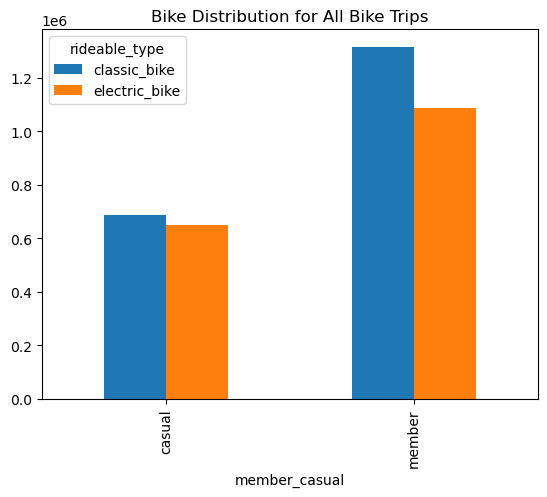

In [11]:
bike_dist = combined_df.groupby('member_casual')['rideable_type'].value_counts().unstack()
print(bike_dist)
bike_dist.plot(kind='bar', title='Bike Distribution for All Bike Trips')


In [12]:
combined_df.groupby('member_casual')['rideable_type'].value_counts(normalize=True)*100

member_casual  rideable_type
casual         classic_bike     51.285662
               electric_bike    48.714338
member         classic_bike     54.755987
               electric_bike    45.244013
Name: proportion, dtype: float64

#### **Average Trip Duration**

In [13]:
print("Average trip duration for members:", member_data['trip_duration'].mean())
print("Average trip duration for casual riders:", casual_data['trip_duration'].mean())

Average trip duration for members: 0 days 00:12:11.207136863
Average trip duration for casual riders: 0 days 00:22:18.404310359


In [14]:
combined_df['month'].value_counts()

month
2025-08    515638
2025-07    494285
2025-09    467761
2025-06    446320
2025-10    417838
2025-05    340707
2025-04    258877
2024-11    245932
2025-03    209832
2024-12    130764
2025-02    109576
2025-01    101211
Freq: M, Name: count, dtype: int64

#### **Total Trips by Month**

member_casual  casual  member
month                        
2024-11         68802  177130
2024-12         28249  102515
2025-01         17090   84121
2025-02         19631   89945
2025-03         61670  148162
2025-04         77018  181859
2025-05        125697  215010
2025-06        193128  253192
2025-07        208733  285552
2025-08        221294  294344
2025-09        172387  295374
2025-10        143511  274327


Text(0.5, 1.0, 'Number of Bike Trips Each Month by Casual Riders and Members for Nov 2024 - Oct 2025')

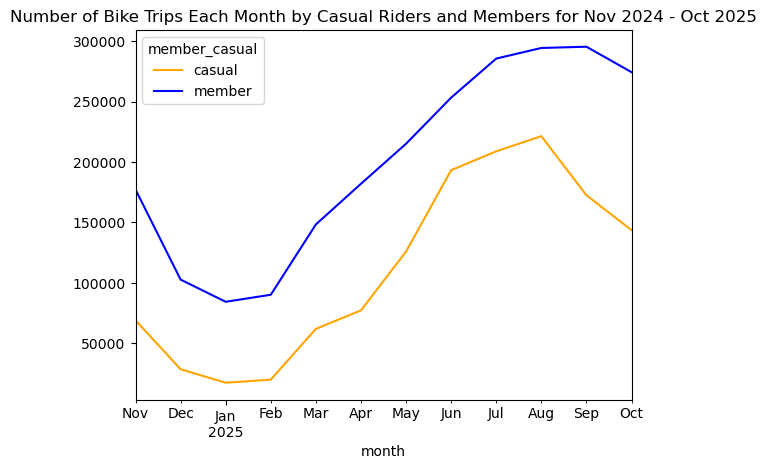

In [15]:
monthly_trips = combined_df.groupby(['month', 'member_casual'])['month'].value_counts().unstack()
print(monthly_trips)
monthly_trips.plot(kind='line', color=['orange', 'blue'])
plt.title('Number of Bike Trips Each Month by Casual Riders and Members for Nov 2024 - Oct 2025')

#### **Total Trips by Day**

member_casual  casual  member
day                          
0              159515  359523
1              150478  388286
2              143305  369494
3              166065  380288
4              213018  355397
5              275483  288656
6              229346  259887


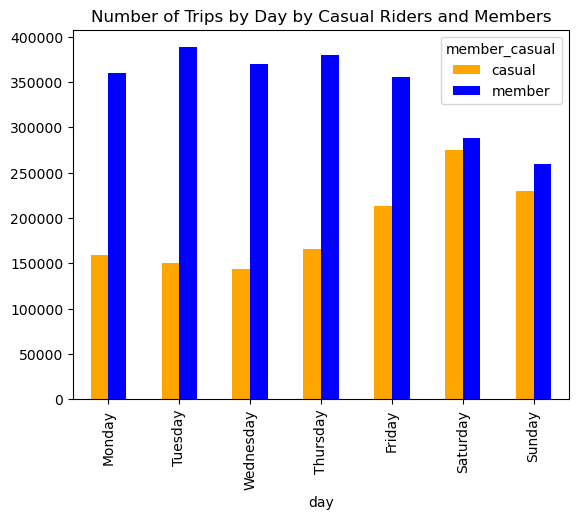

In [16]:
daily_trips = combined_df.groupby(['day', 'member_casual'])['day'].value_counts().unstack()
print(daily_trips)
daily_plot = daily_trips.plot(kind='bar', color=['orange', 'blue'])
plt.title('Number of Trips by Day by Casual Riders and Members')
daily_plot.set_xticklabels(labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.show()

#### **Total Trips by Hour**

member_casual  casual  member
start_hour                   
0               22723   17633
1               14261   10327
2                9114    5887
3                4988    3941
4                4042    5278
5                7241   23884
6               18197   74438
7               34431  149133
8               48732  182438
9               49161  114945
10              60999   98509
11              77914  114373
12              90549  129264
13              92331  126517
14              97195  128816
15             106735  162419
16             121655  232286
17             128050  261815
18             105344  193663
19              76012  131211
20              54663   89234
21              46149   68320
22              38721   48140
23              28003   29060


Text(0.5, 0, 'Starting Hour (0 = Midnight)')

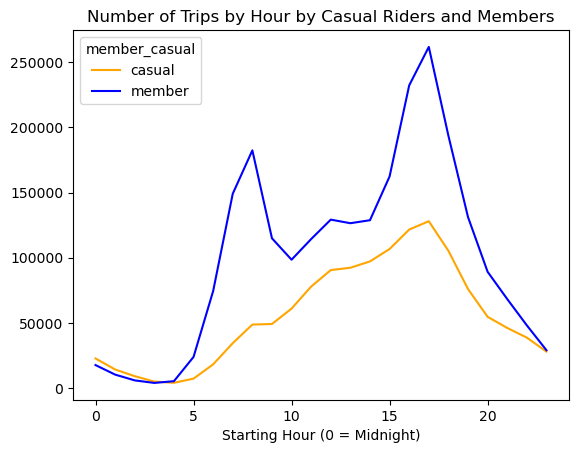

In [17]:
hourly_trips = combined_df.groupby(['start_hour', 'member_casual'])['start_hour'].value_counts().unstack()
print(hourly_trips)
hourly_trips.plot(kind='line', color=['orange', 'blue'])
plt.title('Number of Trips by Hour by Casual Riders and Members')
plt.xlabel('Starting Hour (0 = Midnight)')

#### **Total Trips Each Day, by Hour**

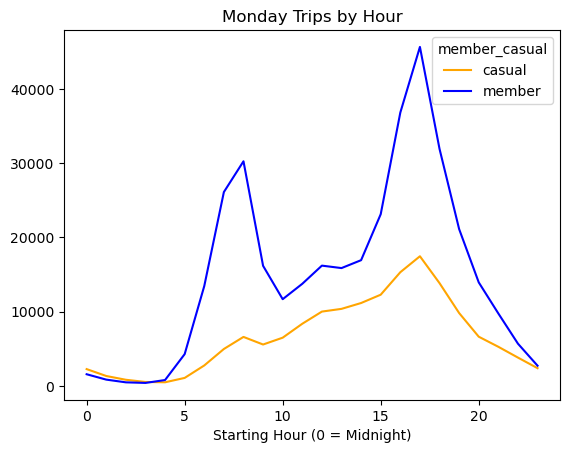

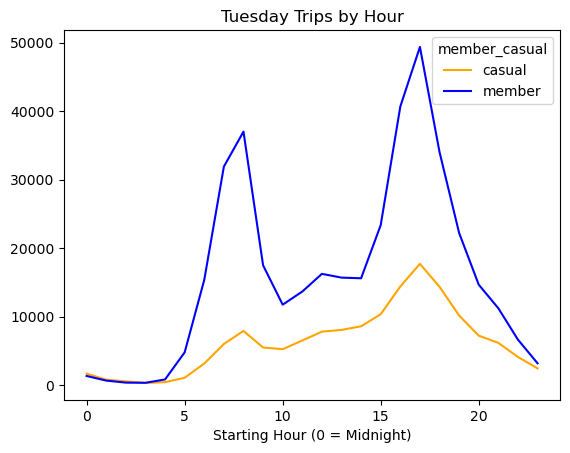

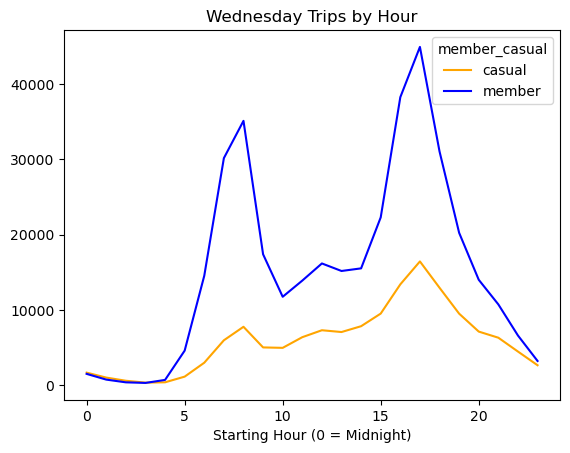

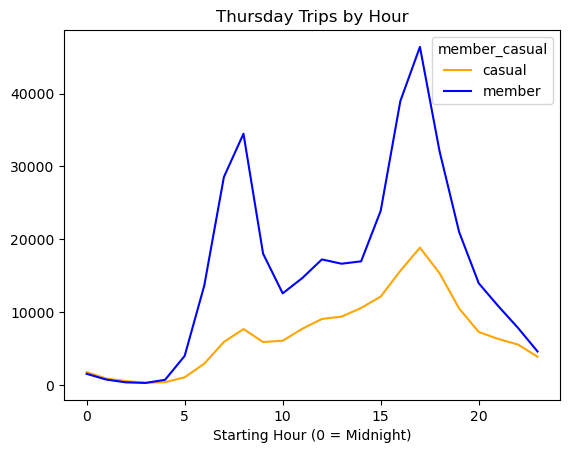

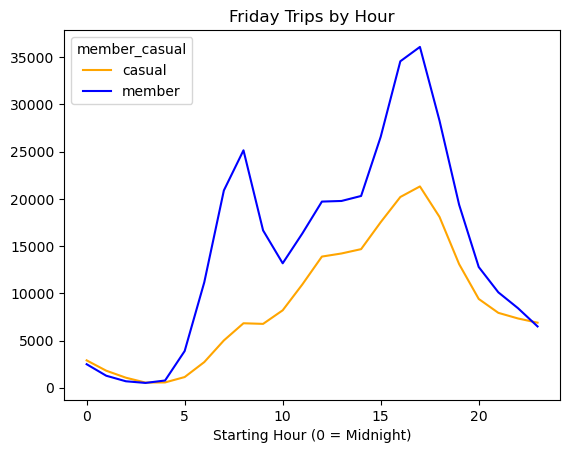

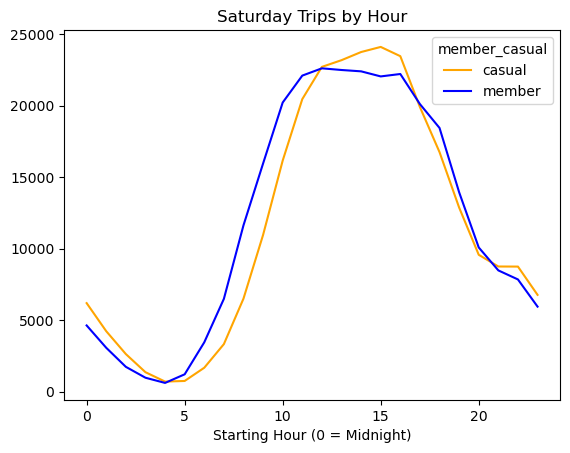

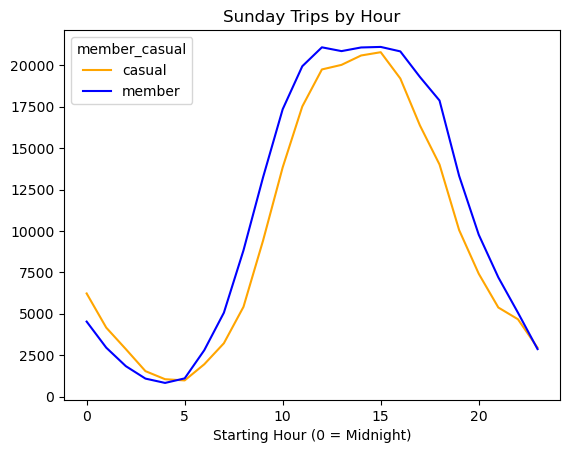

In [18]:
unique_days = [0, 1, 2, 3, 4, 5, 6]
unique_days.sort()
labels=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
for i in unique_days:
    day_trips = combined_df[combined_df['day'] == i]
    day_hourly_trips = day_trips.groupby(['start_hour', 'member_casual'])['start_hour'].value_counts().unstack()
    day_hourly_trips.plot(kind='line', color=['orange', 'blue'])
    plt.title(f'{labels[i]} Trips by Hour')
    plt.xlabel('Starting Hour (0 = Midnight)')

#### **Top Starting Stations for Both Groups**

Text(0, 0.5, 'Number of trips')

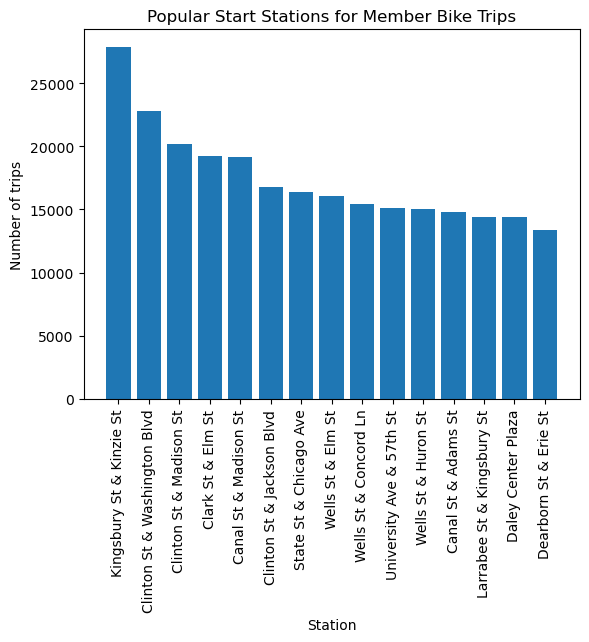

In [19]:
member_starts = member_data['start_station_name'].value_counts()[:15]

plt.bar(member_starts.keys(), member_starts)
plt.xticks(rotation='vertical')
plt.title('Popular Start Stations for Member Bike Trips')
plt.xlabel('Station')
plt.ylabel('Number of trips')

Text(0, 0.5, 'Number of trips')

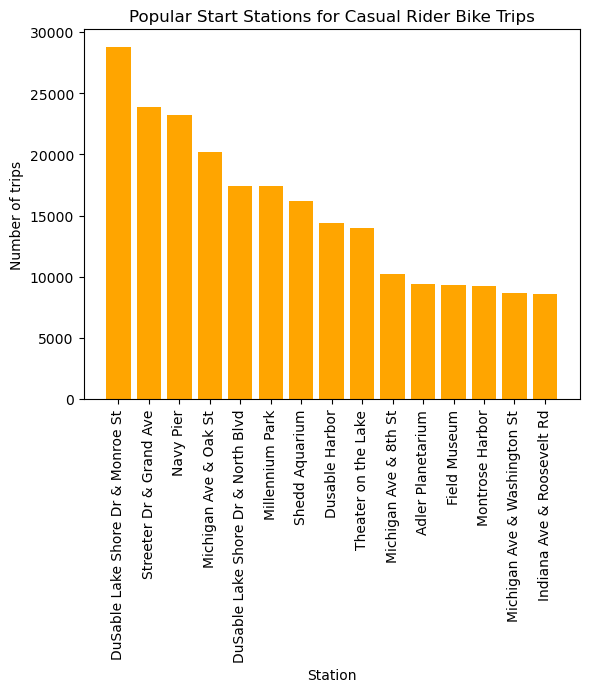

In [20]:
casual_starts = casual_data['start_station_name'].value_counts()[:15]

plt.bar(casual_starts.keys(), casual_starts, color='orange')
plt.xticks(rotation='vertical')
plt.title('Popular Start Stations for Casual Rider Bike Trips')
plt.xlabel('Station')
plt.ylabel('Number of trips')

#### **Top Ending Stations for Both Groups**

Text(0, 0.5, 'Number of trips')

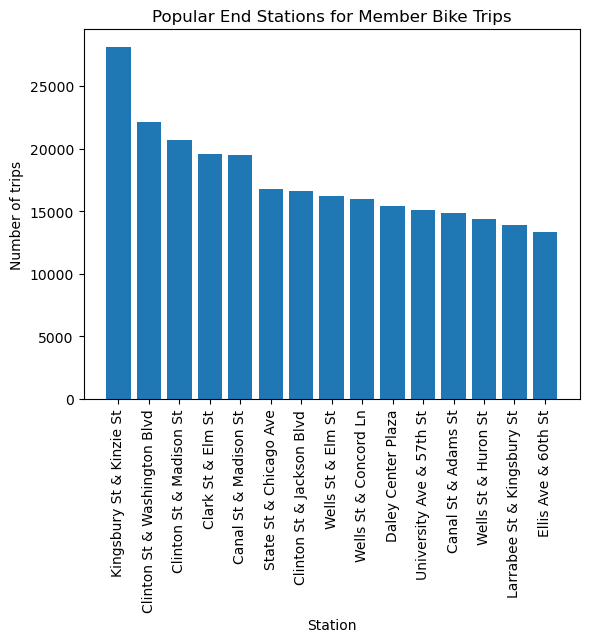

In [21]:
member_ends = member_data['end_station_name'].value_counts()[:15]

plt.bar(member_ends.keys(), member_ends)
plt.xticks(rotation='vertical')
plt.title('Popular End Stations for Member Bike Trips')
plt.xlabel('Station')
plt.ylabel('Number of trips')

Text(0, 0.5, 'Number of trips')

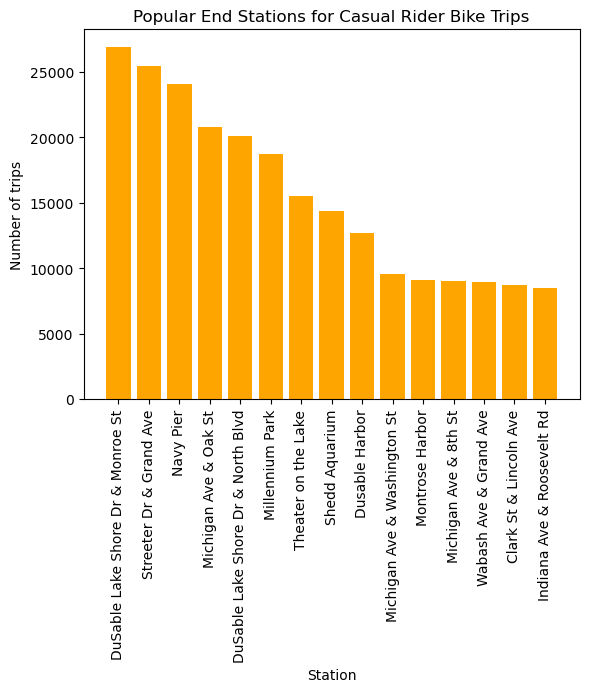

In [22]:
casual_ends = casual_data['end_station_name'].value_counts()[:15]

plt.bar(casual_ends.keys(), casual_ends, color='orange')
plt.xticks(rotation='vertical')
plt.title('Popular End Stations for Casual Rider Bike Trips')
plt.xlabel('Station')
plt.ylabel('Number of trips')